# TRACK-FA Merge and Quality Control

This notebook prepares the paired TRACK-FA dataset used by the progression-biomarker notebooks.

**What this notebook checks**

- Raw TRACK-FA source tables are merged into visit-level and paired interval tables.
- Clinical scores keep their visit suffixes, such as `mfars_total_v1`, `mfars_total_v2`, and `mfars_total_v3`.
- Paired intervals such as `V1V2` and `V2V3` are preserved for disease-progression analysis.
- Subject identifiers are available for grouped cross-validation, so both intervals from the same participant can be held out together.

**Output to inspect:** merged table shapes, visit coverage, missingness summaries, clinical deltas, and final imaging-feature groups.


In [1]:
# Setup: load dependencies, configuration, and data paths.

import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find the project root containing src/ and data/.")


_REPO_ROOT = find_project_root(Path.cwd())
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import pandas as pd

from src.data.audit import add_visit_time, analysis_population_counts, audit_visit_patterns, visit_pattern_table
from src.data.missingness import feature_missingness_report, feature_visit_site_missingness_matrix, followup_missingness_analysis

from src.data.mri_qc import harmonisation_leakage_policy, mri_outlier_table, plot_feature_distributions_by_site, site_effect_screen

from src.data.trackfa import (
    run_merge,
    qc_long,
    qc_pairs,
    imaging_coverage,
    dry_run_logo_split,
    delta_summary_table,
    feature_catalog,
)


## 1. Merge Source Tables

This cell runs the configured TRACK-FA merge and displays the main visit-level and paired outputs. The purpose is to confirm that the data assembly step succeeds before any modelling notebook uses the processed files.


In [2]:
# Run the TRACK-FA merge and display paired analysis tables.

long_df, pairs_df = run_merge(save=False, verbose=True)
long_df = add_visit_time(long_df, visit_col="visit", output_col="time_years")
print('trackfa_long:', long_df.shape)
print('trackfa_pairs:', pairs_df.shape)

display(long_df.head())
display(pairs_df.head())


[trackfa_pairs] dropped 2 rows with missing clinical values (before=298, after=296). Removed by pair: {'V1V2': 1, 'V2V3': 1}
[trackfa_pairs] dropped 222 rows failing strict sheet completeness (before=296, after=74). Removed by pair: {'V1V2': 114, 'V2V3': 108}
[trackfa_pairs] failed-sheet counts (rows where this condition fails): POMs_complete_baseline=147, POMs_complete_followup=167, BrainSpineMorph_complete_baseline=29, BrainSpineMorph_complete_followup=26, BrainDTI_complete_baseline=42, BrainDTI_complete_followup=40
[trackfa_pairs] top missing columns among removed rows:
delta_tNAA_myo_Ins       0.653153
delta_DN_suscept         0.621622
delta_DN_vol             0.621622
tNAA_myo_Ins_followup    0.527027
DN_suscept_baseline      0.436937
DN_vol_baseline          0.436937
DN_suscept_followup      0.432432
DN_vol_followup          0.432432
tNAA_myo_Ins_baseline    0.400901
delta_MD_PCR             0.216216
delta_MD_Cing_h          0.216216
delta_MD_Cing            0.216216
delta_MD_EC 

,subject_id,visit,site,age,gender,gaa_1,gaa_2,onset_age,disease_duration,mfars_total,...,AD_ILF_IFOF,AD_EC,AD_Cing,AD_Cing_h,AD_Fx_ST,AD_SLF,AD_SFOF,AD_UNC,AD_Tap,time_years
0,AAN001,1,2.0,26.3,2.0,612,912,15.0,11.3,27.666667,...,0.001158,0.001028,0.001057,0.001129,0.001305,0.000962,0.000964,0.001128,0.001614,0.0
1,AAN001,2,2.0,26.3,2.0,612,912,15.0,11.3,19.000000,...,0.001198,0.001032,0.001095,0.001105,0.001295,0.000973,0.000997,0.001126,0.001638,1.0
2,AAN001,3,2.0,26.3,2.0,612,912,15.0,11.3,29.000000,...,0.001186,0.001029,0.001079,0.001125,0.001270,0.000980,0.001004,0.001109,0.001651,2.0
3,AAN002,1,2.0,25.6,2.0,520,930,11.0,14.6,41.000000,...,0.001271,0.001051,0.001091,0.001101,0.001320,0.001003,0.001001,0.001127,0.001717,0.0
4,AAN002,2,2.0,25.6,2.0,520,930,11.0,14.6,51.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


,patient_id,site,age,gender,gaa_1,gaa_2,onset_age,disease_duration,mfars_total_baseline,mfars_total_followup,...,delta_AD_SLF,AD_SFOF_baseline,AD_SFOF_followup,delta_AD_SFOF,AD_UNC_baseline,AD_UNC_followup,delta_AD_UNC,AD_Tap_baseline,AD_Tap_followup,delta_AD_Tap
0,AAN005_V1V2,2.0,32.6,1.0,512,712,21.0,11.6,23.333333,39.500000,...,0.000001,0.001019,0.001042,0.000023,0.001135,0.001114,-2.122000e-05,0.001552,0.001542,-0.000010
1,AAN006_V1V2,2.0,13.8,1.0,660,830,6.0,7.8,28.000000,29.000000,...,-0.000031,0.001202,0.001174,-0.000029,0.001270,0.001232,-3.796500e-05,0.001668,0.001678,0.000010
2,AAN009_V1V2,2.0,16.7,1.0,845,960,11.0,5.7,53.666667,54.666667,...,-0.000014,0.001085,0.001074,-0.000011,0.001096,0.001112,1.629500e-05,0.001698,0.001706,0.000008
3,AAN026_V1V2,2.0,18.0,2.0,660,760,5.0,13.0,23.666667,28.000000,...,-0.000002,0.000982,0.000979,-0.000004,0.001268,0.001248,-1.984500e-05,0.001603,0.001615,0.000012
4,AAN028_V1V2,2.0,12.8,1.0,560,900,7.0,5.8,16.000000,25.333333,...,0.000002,0.001079,0.001028,-0.000051,0.001189,0.001189,6.000000e-07,0.001633,0.001540,-0.000093


## 2. Validate Visit-Level Clinical Fields

Clinical scores must remain visit-specific in the raw merged table. The expected naming pattern is suffix-based, for example `mfars_total_v1`, `mfars_total_v2`, and `mfars_total_v3`.


rows: 522
cols: 162
unique subjects: 174


,n
visit,
1,174
2,174
3,174


,demo,clinical,imaging
0,0.0,0.060664,0.199068


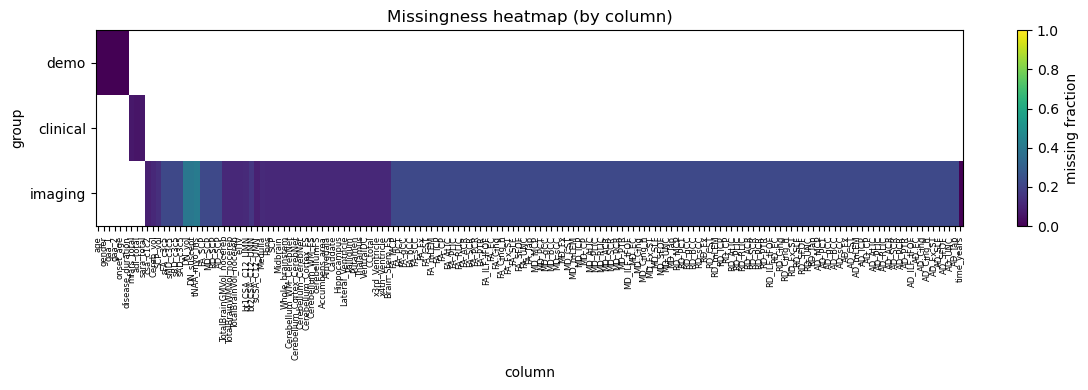

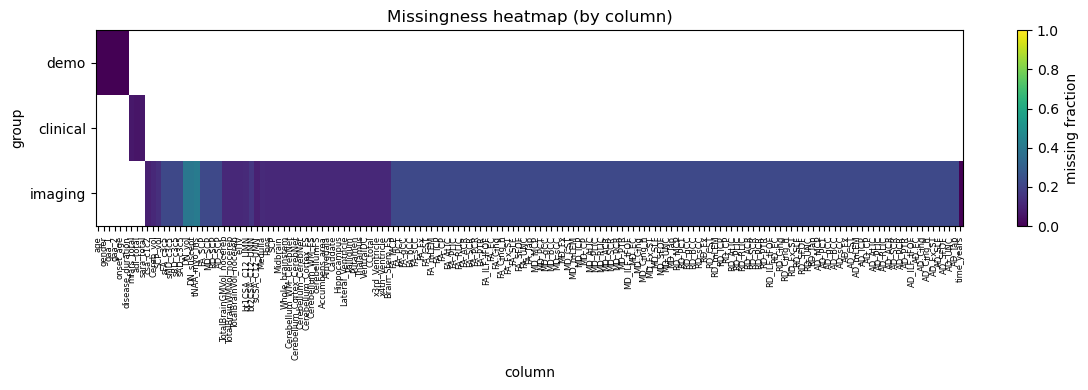

In [3]:
# Check the visit-level table for expected subjects, visits, and clinical scores.

out = qc_long(long_df)
print('rows:', out['n_rows'])
print('cols:', out['n_cols'])
print('unique subjects:', out['n_subjects'])
display(out['visit_distribution'])
display(out['missingness_by_group'])

fig = out.get('missing_heatmap_fig')
if fig is not None:
    display(fig)
else:
    print('missing heatmap unavailable:', out.get('missing_heatmap_error'))


## 2a. Machine-Readable Visit Pattern Audit


In [4]:
# Run the reusable visit-pattern audit from src and display it inline.
visit_audit = audit_visit_patterns(long_df, subject_col="subject_id", visit_col="visit")
pattern_table = visit_pattern_table(visit_audit)
population_table = analysis_population_counts(long_df, subject_col="subject_id", visit_col="visit")
summary_table = pd.DataFrame([{k: v for k, v in visit_audit.items() if k != "patterns"}])
print("Canonical visit-time mapping is attached in long_df['time_years'].")
print("Visit-pattern meanings requested for the longitudinal audit")
display(pattern_table)
print("Analysis populations")
display(population_table)
display(summary_table)


Canonical visit-time mapping is attached in long_df['time_years'].
Visit-pattern meanings requested for the longitudinal audit


,pattern,meaning,n_subjects,percent_subjects
0,111,"V1, V2, and V3 available",174,100.0
1,110,V1 and V2 available; V3 missing,0,0.0
2,101,V1 and V3 available; V2 missing,0,0.0
3,011,V2 and V3 available; V1 missing,0,0.0
4,100,Only V1 available,0,0.0
5,010,Only V2 available,0,0.0
6,001,Only V3 available,0,0.0


Analysis populations


,population,required_visits,n_subjects,role
0,V1-V3 primary cohort,"V1,V3",174,Primary 24-month annualised paired change
1,V1-V2 cohort,"V1,V2",174,Secondary 12-month interval
2,V2-V3 cohort,"V2,V3",174,Secondary 12-month interval
3,Complete V1-V2-V3 cohort,"V1,V2,V3",174,Consistency and trajectory checks
4,All longitudinal with any adjacent pair,"V1,V2 or V2,V3",174,Maximum adjacent-interval sensitivity check


,n_subjects,n_v1,n_v2,n_v3,n_v1_v2,n_v2_v3,n_v1_v3,n_complete
0,174,174,174,174,174,174,174,174


## 3. Validate Paired Progression Rows

Each paired row represents a follow-up-minus-baseline interval. This is the unit used to compute progression deltas for imaging scores and clinical benchmarks.


,n
1,
V1V2,43
V2V3,31


subjects with both pair types: 21
subjects with one pair type: 32


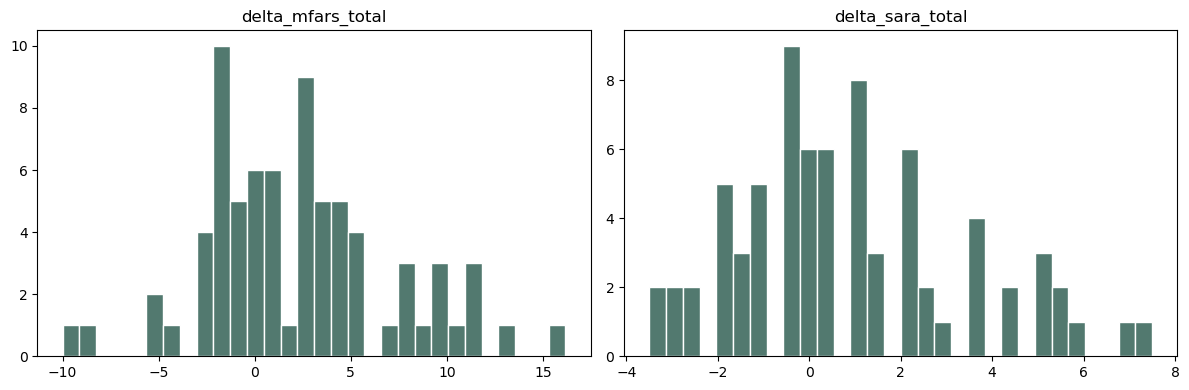

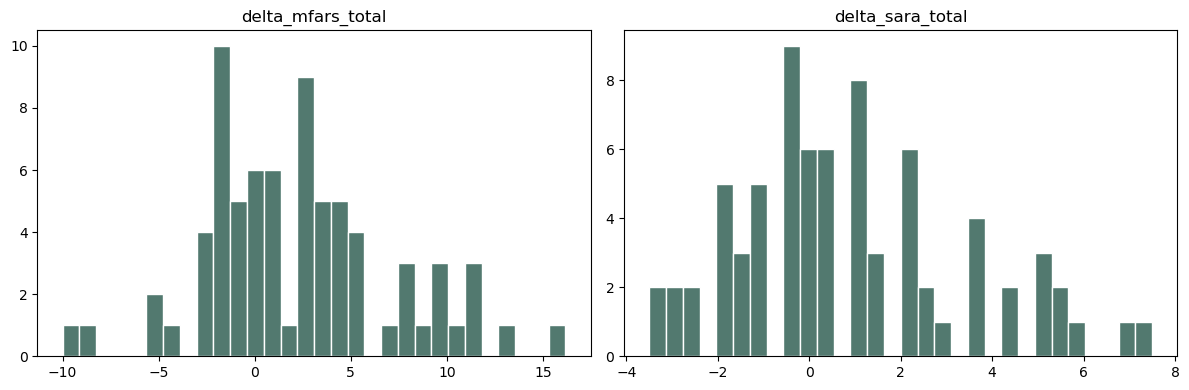

In [5]:
# Check paired baseline/follow-up rows and longitudinal deltas.

out = qc_pairs(pairs_df)
display(out['pair_counts'])
print('subjects with both pair types:', out['subjects_with_both_pair_types'])
print('subjects with one pair type:', out['subjects_with_one_pair_type'])

fig = out.get('delta_hist_fig')
if fig is not None:
    display(fig)
else:
    print('delta hist unavailable:', out.get('delta_hist_error'))


## 4. Review Imaging Feature Availability

This section checks whether imaging features are sufficiently populated after merging. Features with heavy missingness can destabilise covariance-based and interaction models.


In [6]:
# Summarize imaging-feature availability across the merged dataset.

coverage = imaging_coverage(long_df, missing_threshold=0.20)
flagged = coverage[coverage['flag_gt20pct_missing']].copy()
print('n imaging features:', len(coverage))
print('flagged (>20% missing):', len(flagged))
display(flagged.head(30))


n imaging features: 150
flagged (>20% missing): 115


,frac_non_nan,frac_missing,flag_gt20pct_missing
sMD_c3c5,0.781609,0.218391,True
sFA_c3c5,0.781609,0.218391,True
sRD_c3c5,0.781609,0.218391,True
sAD_c3c5,0.781609,0.218391,True
RD_UNC,0.779693,0.220307,True
RD_Fx,0.779693,0.220307,True
RD_SLF,0.779693,0.220307,True
RD_Fx_ST,0.779693,0.220307,True
RD_Cing_h,0.779693,0.220307,True
RD_Cing,0.779693,0.220307,True


## 4a. Reusable Missingness and Follow-Up Availability Audit


Global imaging-feature missingness


,feature,missing_pct
0,tNAA_myo_Ins,0.417625
1,DN_suscept,0.394636
2,DN_vol,0.394636
3,AD_ACR,0.220307
4,AD_ALIC,0.220307
5,AD_CP,0.220307
6,AD_CST,0.220307
7,AD_Cing,0.220307
8,AD_Cing_h,0.220307
9,AD_EC,0.220307


Feature x Visit x Site missingness matrix (proportion missing)


visit_site,V1|1.0,V1|2.0,V1|3.0,V1|5.0,V1|6.0,V1|7.0,V2|1.0,V2|2.0,V2|3.0,V2|5.0,V2|6.0,V2|7.0,V3|1.0,V3|2.0,V3|3.0,V3|5.0,V3|6.0,V3|7.0
feature,,,,,,,,,,,,,,,,,,
AD_ACR,0.083333,0.204545,0.20,0.200000,0.043478,0.000,0.125000,0.386364,0.25,0.218182,0.043478,0.000,0.166667,0.409091,0.35,0.254545,0.304348,0.000
AD_ALIC,0.083333,0.204545,0.20,0.200000,0.043478,0.000,0.125000,0.386364,0.25,0.218182,0.043478,0.000,0.166667,0.409091,0.35,0.254545,0.304348,0.000
AD_CP,0.083333,0.204545,0.20,0.200000,0.043478,0.000,0.125000,0.386364,0.25,0.218182,0.043478,0.000,0.166667,0.409091,0.35,0.254545,0.304348,0.000
AD_CST,0.083333,0.204545,0.20,0.200000,0.043478,0.000,0.125000,0.386364,0.25,0.218182,0.043478,0.000,0.166667,0.409091,0.35,0.254545,0.304348,0.000
AD_Cing,0.083333,0.204545,0.20,0.200000,0.043478,0.000,0.125000,0.386364,0.25,0.218182,0.043478,0.000,0.166667,0.409091,0.35,0.254545,0.304348,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sRD_c3c5,0.041667,0.272727,0.20,0.181818,0.000000,0.000,0.125000,0.409091,0.25,0.181818,0.000000,0.000,0.166667,0.454545,0.30,0.272727,0.260870,0.000
tNAA_myo_Ins,0.416667,0.363636,0.30,0.272727,0.173913,0.125,0.625000,0.500000,0.40,0.309091,0.217391,0.375,0.541667,0.750000,0.50,0.454545,0.434783,0.625
time_years,0.000000,0.000000,0.00,0.000000,0.000000,0.000,0.000000,0.000000,0.00,0.000000,0.000000,0.000,0.000000,0.000000,0.00,0.000000,0.000000,0.000


Features with concentrated missingness across visit/site strata


,feature,reason,max_missing_pct,min_missing_pct
0,tNAA_myo_Ins,missingness spread >= 0.25 in by_visit,0.551724,0.298851
1,AD_ACR,missingness spread >= 0.25 in by_site,0.333333,0.000000
2,AD_ALIC,missingness spread >= 0.25 in by_site,0.333333,0.000000
3,AD_CP,missingness spread >= 0.25 in by_site,0.333333,0.000000
4,AD_CST,missingness spread >= 0.25 in by_site,0.333333,0.000000
5,AD_Cing,missingness spread >= 0.25 in by_site,0.333333,0.000000
6,AD_Cing_h,missingness spread >= 0.25 in by_site,0.333333,0.000000
7,AD_EC,missingness spread >= 0.25 in by_site,0.333333,0.000000
8,AD_Fx,missingness spread >= 0.25 in by_site,0.333333,0.000000
9,AD_Fx_ST,missingness spread >= 0.25 in by_site,0.333333,0.000000


{'n_baseline_subjects': 174, 'n_complete_v1_v3': 174, 'n_missing_v3': 0}


,variable,group,n,mean,sd,missing_pct,level
0,mfars_total,complete_v1_v3,174,41.944444,13.344917,0.000000,NaN
1,sara_total,complete_v1_v3,173,14.173410,6.911314,0.005747,NaN
2,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,>700
3,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,0775
4,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,0880
5,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,100
6,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,1000
7,gaa_1,complete_v1_v3,2,NaN,NaN,NaN,1050
8,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,1080
9,gaa_1,complete_v1_v3,1,NaN,NaN,NaN,1090


QC 1: MRI feature distributions by site


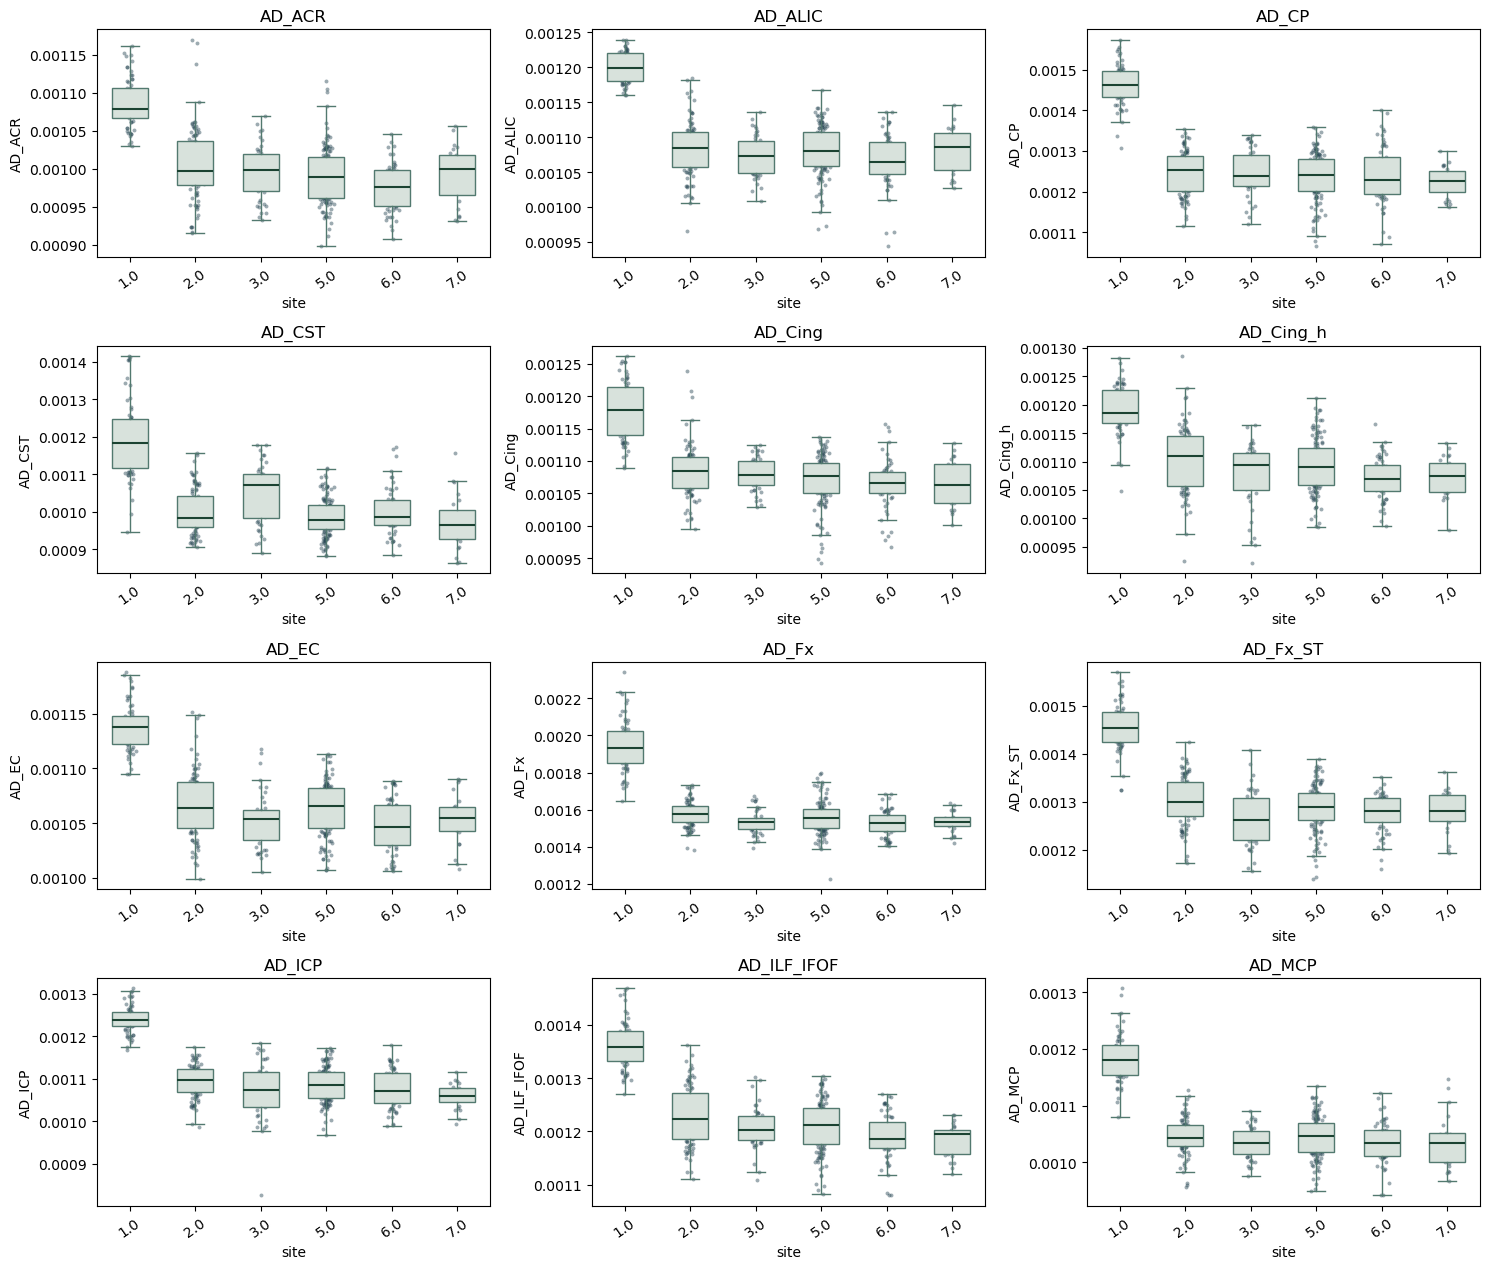

QC 2: Feature ~ Site + Age + Sex + DiseaseSeverity site-effect screen


/Users/robertwang/Documents/New_project/biomarkers/src/data/mri_qc.py:67: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp = df[cols].replace([np.inf, -np.inf], np.nan).dropna(subset=[feature, site_col]).copy()


,feature,n,site_levels,site_r2_delta,site_f,site_p_value,covariates_used
0,AD_gCC,406,6,0.354947,230.783940,1.711480e-41,"age,gender,mfars_total"
1,AD_ILF_IFOF,406,6,0.333896,218.980564,7.634393e-40,"age,gender,mfars_total"
2,AD_bCC,406,6,0.329053,217.870386,1.095325e-39,"age,gender,mfars_total"
3,AD_sCC,406,6,0.331950,211.045200,1.022428e-38,"age,gender,mfars_total"
4,AD_Fx,406,6,0.338124,205.972086,5.467924e-38,"age,gender,mfars_total"
5,AD_RLIC,406,6,0.310314,192.778823,4.579939e-36,"age,gender,mfars_total"
6,AD_SLF,406,6,0.296420,179.654694,4.143461e-34,"age,gender,mfars_total"
7,MD_gCC,406,6,0.299375,178.344387,6.533758e-34,"age,gender,mfars_total"
8,AD_ICP,406,6,0.290658,169.353365,1.530487e-32,"age,gender,mfars_total"
9,AD_CP,406,6,0.259879,159.545489,5.061291e-31,"age,gender,mfars_total"


MRI outliers flagged for review, not mechanical deletion


,visit,site,feature,n,n_outliers,outlier_pct,lower_fence,upper_fence,min_flagged,max_flagged
0,2,1.0,MD_Cing_h,21,4,0.190476,0.000740,0.000793,0.000714,0.000829
1,1,1.0,MD_PCT,22,3,0.136364,0.000499,0.000949,0.000997,0.001076
2,2,2.0,RD_gCC,27,3,0.111111,0.000297,0.000520,0.000531,0.000568
3,2,5.0,MD_Fx,43,3,0.069767,0.000461,0.001368,0.001375,0.001447
4,3,5.0,RD_PCR,41,3,0.073171,0.000480,0.000590,0.000462,0.000473
5,1,1.0,AD_PCT,22,2,0.090909,0.000733,0.001281,0.001379,0.001399
6,1,1.0,RD_PCT,22,2,0.090909,0.000274,0.000891,0.000895,0.000925
7,1,2.0,RD_SCR,35,2,0.057143,0.000386,0.000567,0.000577,0.000603
8,1,3.0,MD_gCC,16,2,0.125000,0.000646,0.000760,0.000784,0.000797
9,1,3.0,RD_gCC,16,2,0.125000,0.000291,0.000543,0.000547,0.000555


QC 3: harmonisation leakage policy


,rule,reason
0,Estimate harmonisation parameters inside each ...,Using held-out subjects to estimate site/scann...
1,Apply learned parameters unchanged to validati...,The outer test fold must remain untouched unti...
2,Preserve within-subject longitudinal change.,The biomarker objective is progression sensiti...
3,Report pre/post site-effect diagnostics if Com...,A site correction is only defensible if it red...


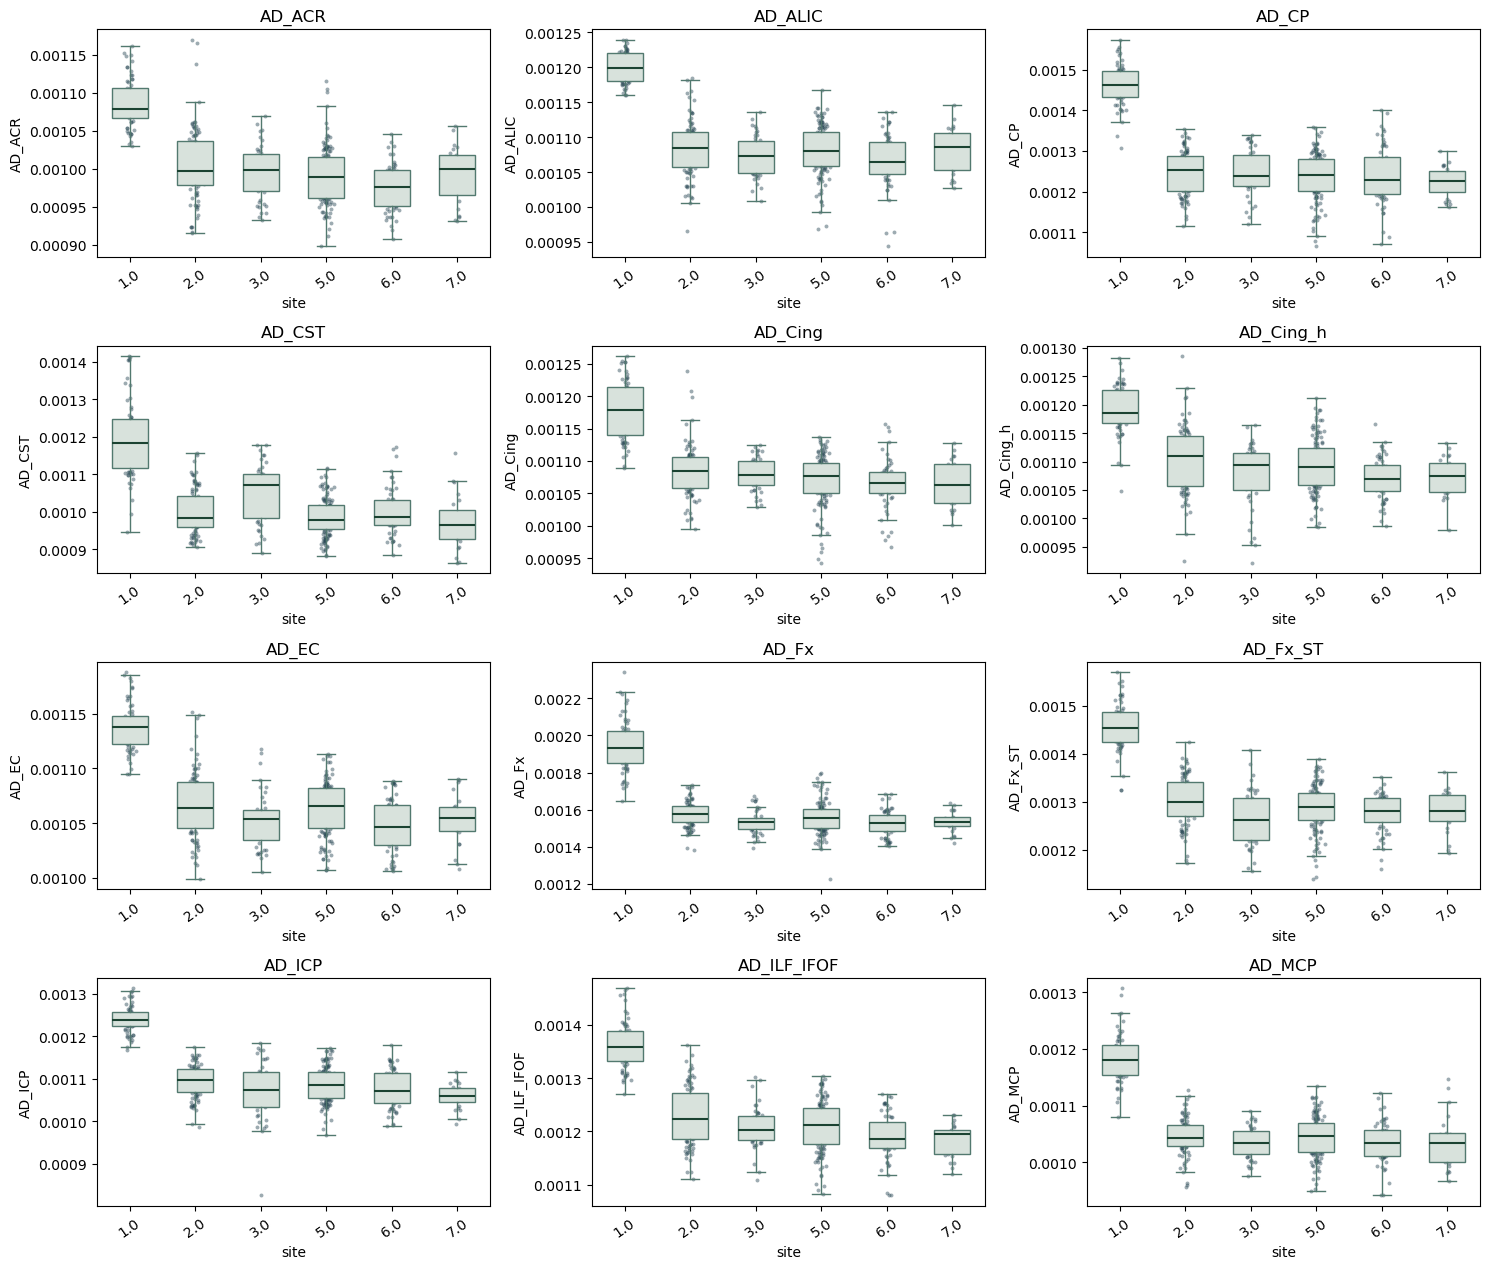

In [7]:
# Run the reusable missingness framework from src and display results in the notebook.
cat_for_audit = feature_catalog(long_df, pairs_df)
long_imaging_columns = cat_for_audit["long_imaging_columns"]
missingness_report = feature_missingness_report(
    long_df,
    long_imaging_columns,
    by=("visit", "site"),
    concentration_spread=0.25,
)
missingness_matrix = feature_visit_site_missingness_matrix(
    long_df,
    long_imaging_columns,
    visit_col="visit",
    site_col="site",
)
print("Global imaging-feature missingness")
display(missingness_report["global"].head(30))
print("Feature x Visit x Site missingness matrix (proportion missing)")
display(missingness_matrix["matrix"])
print("Features with concentrated missingness across visit/site strata")
display(missingness_report["flags"].head(30))

followup_report = followup_missingness_analysis(
    long_df,
    subject_col="subject_id",
    visit_col="visit",
    variables=(
        "mfars_total",
        "sara_total",
        "gaa_1",
        "gaa_2",
        "age",
        "onset_age",
        "disease_duration",
        "site",
        "gender",
    ),
    fit_logistic=False,
)
print({
    "n_baseline_subjects": followup_report["n_baseline_subjects"],
    "n_complete_v1_v3": followup_report["n_complete_v1_v3"],
    "n_missing_v3": followup_report["n_missing_v3"],
})
display(followup_report["comparison"].head(40))

print("QC 1: MRI feature distributions by site")
display(plot_feature_distributions_by_site(long_df, long_imaging_columns, site_col="site", max_features=12))
print("QC 2: Feature ~ Site + Age + Sex + DiseaseSeverity site-effect screen")
site_effects = site_effect_screen(long_df, long_imaging_columns, site_col="site")
display(site_effects.head(30))
print("MRI outliers flagged for review, not mechanical deletion")
display(mri_outlier_table(long_df, long_imaging_columns, group_cols=("visit", "site")).head(30))
print("QC 3: harmonisation leakage policy")
display(harmonisation_leakage_policy())


## 5. Confirm Subject-Level Grouping

Cross-validation (CV) must split by participant, not only by interval. If a participant has both `V1V2` and `V2V3`, both intervals must stay together in either training or testing.


In [8]:
# Confirm subject-wise grouping for leave-one-group-out validation.

out = dry_run_logo_split(pairs_df)
print(out)


{'ok': True, 'n_splits': 53}


## 6. Summarise Clinical Change Benchmarks

Clinical Cohen's `d_z` should be computed only from adjacent visit changes: `FARS2-FARS1`, `FARS3-FARS2`, and the equivalent SARA changes where available.


In [9]:
# Summarize follow-up-minus-baseline clinical change.

display(delta_summary_table(pairs_df))


,clinical_score,delta_mean,delta_std,SRM_mean_over_std,n
0,mfars_total,2.250000,4.936526,0.455786,74
1,adl_total,0.675676,2.570156,0.262893,74
2,sara_total,0.851351,2.519417,0.337916,74


## 7. List Final Feature Groups

The modelling notebooks primarily use all imaging features. Feature groups are still useful for audit, interpretation, and checking whether modalities are represented as expected.


In [10]:
# List final feature names by modality category.

cat = feature_catalog(long_df, pairs_df)
print('Demographic columns:')
print(cat['demographic_columns'])
print('\nClinical base names:')
print(cat['clinical_base_names'])
print('\nLong-format imaging columns (n=%d):' % len(cat['long_imaging_columns']))
print(cat['long_imaging_columns'])
print('\nPairs static columns:')
print(cat['pairs_static_columns'])
print('\nPairs clinical columns:')
print(cat['pairs_clinical_columns'])
print('\nPairs imaging base names (n=%d):' % len(cat['pairs_imaging_base_names']))
print(cat['pairs_imaging_base_names'])


Demographic columns:
['site', 'age', 'gender', 'gaa_1', 'gaa_2', 'onset_age', 'disease_duration']

Clinical base names:
['mfars_total', 'adl_total', 'sara_total']

Long-format imaging columns (n=150):
['AD_ACR', 'AD_ALIC', 'AD_CP', 'AD_CST', 'AD_Cing', 'AD_Cing_h', 'AD_EC', 'AD_Fx', 'AD_Fx_ST', 'AD_ICP', 'AD_ILF_IFOF', 'AD_MCP', 'AD_PCR', 'AD_PCT', 'AD_PLIC', 'AD_PTR', 'AD_RLIC', 'AD_SCP', 'AD_SCR', 'AD_SFOF', 'AD_SLF', 'AD_Tap', 'AD_UNC', 'AD_bCC', 'AD_gCC', 'AD_mLEM', 'AD_sCC', 'Accumbens_area', 'Amygdala', 'Brain_Stem_FS', 'CCtotal', 'Caudate', 'Cereb_vol', 'Cerebellum_CerebNet', 'Cerebellum_Cortex_CerebNet', 'Cerebellum_Cortex_FS', 'Cerebellum_WM_CerebNet', 'Cerebellum_WM_FS', 'DN_suscept', 'DN_vol', 'FA_ACR', 'FA_ALIC', 'FA_CP', 'FA_CST', 'FA_Cing', 'FA_Cing_h', 'FA_EC', 'FA_Fx', 'FA_Fx_ST', 'FA_ICP', 'FA_ILF_IFOF', 'FA_MCP', 'FA_PCR', 'FA_PCT', 'FA_PLIC', 'FA_PTR', 'FA_RLIC', 'FA_SCP', 'FA_SCR', 'FA_SFOF', 'FA_SLF', 'FA_Tap', 'FA_UNC', 'FA_bCC', 'FA_gCC', 'FA_mLEM', 'FA_sCC', 'Hi